<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/latihanNo1aJobsheet8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print("5 Data Pertama Iris:")
print(df.head())

5 Data Pertama Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
# gunakan semua fitur numerik yang ada
X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

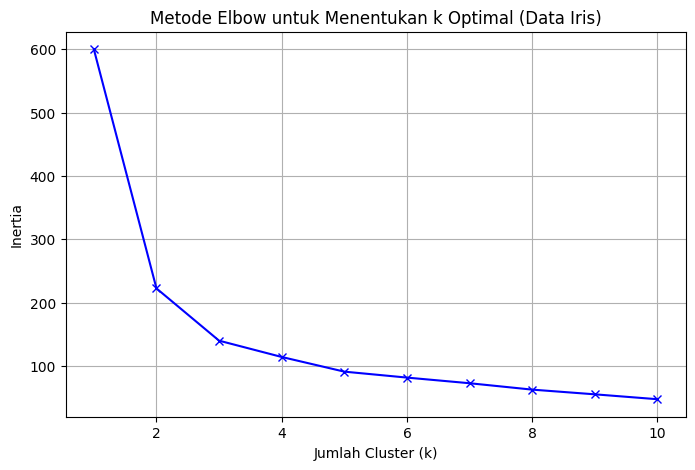

In [4]:
# Elbow Method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k Optimal (Data Iris)')
plt.grid(True)
plt.show()

In [5]:
# Buat Model KMeans (gunakan k=3 sesuai spesies Iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nHasil Clustering (5 data pertama):")
print(df.head())


Hasil Clustering (5 data pertama):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


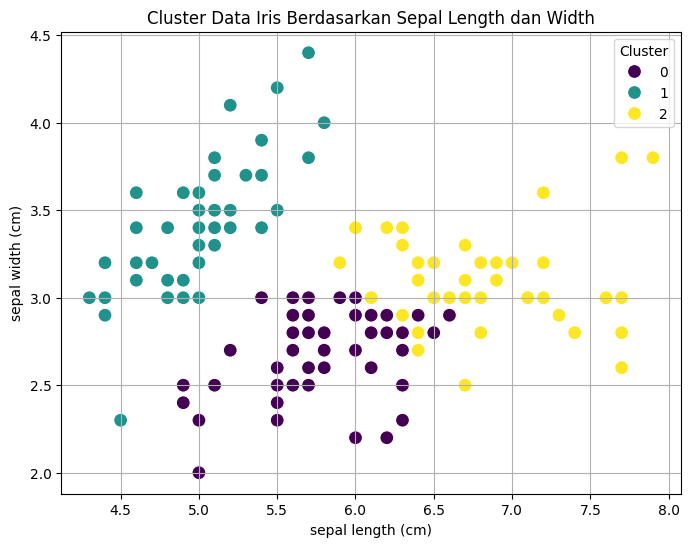

In [6]:
# Visualisasi Hasil Clustering
# visualisasikan Sepal Length vs Sepal Width
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=df['Cluster'], palette='viridis', s=100)
plt.title('Cluster Data Iris Berdasarkan Sepal Length dan Width')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [7]:
# Evaluasi Performa (Silhouette Score & Inertia)
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")


Silhouette Score: 0.460
Inertia (k=3): 139.820
